In [1]:
print("===== CASE STUDY 2: CREDIT CARD FRAUD DETECTION =====")
print("Model: XGBoost")
print("Imbalance Handling: SMOTE")
print("Goal: Detect fraudulent credit card transactions")

===== CASE STUDY 2: CREDIT CARD FRAUD DETECTION =====
Model: XGBoost
Imbalance Handling: SMOTE
Goal: Detect fraudulent credit card transactions


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/mlg-ulb/creditcardfraud/master/creditcard.csv"

data = pd.read_csv(url)

print("Dataset Shape:", data.shape)
data.head()

HTTPError: HTTP Error 404: Not Found

In [8]:
from google.colab import files

uploaded = files.upload()

In [9]:
data = pd.read_csv("creditcard.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
print("===== CLASS DISTRIBUTION =====")

print(data['Class'].value_counts())

print("\nPercentage:")
print(data['Class'].value_counts(normalize=True) * 100)

===== CLASS DISTRIBUTION =====
Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [11]:
print("===== MISSING VALUES =====")

print(data.isnull().sum().sum())

===== MISSING VALUES =====
0


In [12]:
X = data.drop('Class', axis=1)
y = data['Class']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


In [14]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42, sampling_strategy=0.1)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1     22745
Name: count, dtype: int64


In [15]:
!pip install xgboost -q

from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [16]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [17]:
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("First 10 fraud probabilities:")
print(y_prob[:10])

Predictions generated successfully!
First 10 fraud probabilities:
[2.8885642e-04 6.7786023e-05 2.1217533e-03 1.4193334e-04 1.5368543e-03
 3.9751254e-04 8.7264350e-05 2.2593857e-04 5.1748403e-04 1.1139031e-04]


In [18]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("===== XGBOOST MODEL EVALUATION =====")
print("ROC-AUC Score:", round(roc_auc, 4))

===== XGBOOST MODEL EVALUATION =====
ROC-AUC Score: 0.9785


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.3, 0.2, 0.1]

print("===== THRESHOLD TUNING =====")

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\nThreshold:", threshold)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-Score:", round(f1, 4))

===== THRESHOLD TUNING =====

Threshold: 0.5
Precision: 0.7265
Recall: 0.8673
F1-Score: 0.7907

Threshold: 0.3
Precision: 0.5541
Recall: 0.8878
F1-Score: 0.6824

Threshold: 0.2
Precision: 0.4372
Recall: 0.8878
F1-Score: 0.5859

Threshold: 0.1
Precision: 0.2871
Recall: 0.9082
F1-Score: 0.4363


In [20]:
from sklearn.metrics import confusion_matrix, classification_report

selected_threshold = 0.50

y_pred = (y_prob >= selected_threshold).astype(int)

print("===== FINAL XGBOOST RESULTS =====")
print("Selected Threshold:", selected_threshold)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== FINAL XGBOOST RESULTS =====
Selected Threshold: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.87      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56832    32]
 [   13    85]]


===== TOP 10 IMPORTANT FEATURES =====
V14    0.612881
V17    0.052976
V12    0.047127
V10    0.037627
V4     0.032051
V7     0.017224
V3     0.014549
V13    0.012823
V1     0.012699
V8     0.012269
dtype: float32


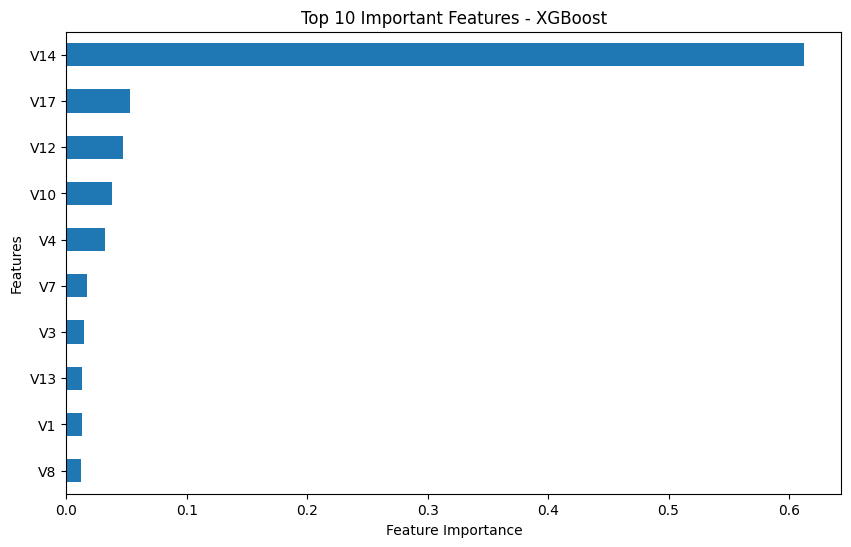

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

top_features = feature_importance.sort_values(ascending=False).head(10)

print("===== TOP 10 IMPORTANT FEATURES =====")
print(top_features)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - XGBoost")

plt.show()

In [22]:
print("===== CASE STUDY 2 FINAL SUMMARY =====")

print("Dataset: Credit Card Fraud Detection")
print("Model: XGBoost")
print("Imbalance Handling: SMOTE")
print("ROC-AUC:", 0.9785)

print("\nSelected Threshold:", 0.50)
print("Precision:", 0.7265)
print("Recall:", 0.8673)
print("F1-Score:", 0.7907)

print("\nConfusion Matrix:")
print("TN = 56832")
print("FP = 32")
print("FN = 13")
print("TP = 85")

print("\nMost Important Feature: V14")

===== CASE STUDY 2 FINAL SUMMARY =====
Dataset: Credit Card Fraud Detection
Model: XGBoost
Imbalance Handling: SMOTE
ROC-AUC: 0.9785

Selected Threshold: 0.5
Precision: 0.7265
Recall: 0.8673
F1-Score: 0.7907

Confusion Matrix:
TN = 56832
FP = 32
FN = 13
TP = 85

Most Important Feature: V14


In [23]:
print("===== CONCLUSION =====")

print("XGBoost performed well for credit card fraud detection.")
print("SMOTE was used to handle the highly imbalanced dataset.")
print("The model achieved a ROC-AUC of 0.9785.")
print("At the selected threshold of 0.50, the model achieved:")
print("- Precision: 0.7265")
print("- Recall: 0.8673")
print("- F1-Score: 0.7907")
print("Only 13 fraud transactions were missed (False Negatives).")
print("V14 was the most important feature according to XGBoost.")

===== CONCLUSION =====
XGBoost performed well for credit card fraud detection.
SMOTE was used to handle the highly imbalanced dataset.
The model achieved a ROC-AUC of 0.9785.
At the selected threshold of 0.50, the model achieved:
- Precision: 0.7265
- Recall: 0.8673
- F1-Score: 0.7907
Only 13 fraud transactions were missed (False Negatives).
V14 was the most important feature according to XGBoost.
